# DAMICORE structural baseline for female-victim reports

## Goal

Build one deterministic 500-report corpus, run or reuse DAMICORE, and inspect its structural groups. The cluster identifiers are exploratory structural results, not confirmed abuse typologies.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or notebooks directory.")

source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

import html
import json
from copy import deepcopy
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio import Phylo
from damicore import estimate, run
from IPython.display import HTML, display
from psycopg import sql

from disque100_research import ArtifactPaths, ExperimentConfig
from disque100_research.artifacts import (
    assert_public_artifact_safe,
    write_manifest,
)
from disque100_research.database import query_frame

CONFIG = ExperimentConfig.load(PROJECT_ROOT / "experiments" / "female_abuse_2026_h1.toml")
PATHS = ArtifactPaths.for_experiment(PROJECT_ROOT, CONFIG)
PATHS.ensure_directories()

CORPUS_DIR = PATHS.work_damicore / "corpus"
RUN_DIR = PATHS.work_damicore / "run"
MEMBERSHIP_FILE = PATHS.work_damicore / "membership.csv"
COHORT_MANIFEST_FILE = PATHS.work_damicore / "cohort-manifest.csv"
TREE_PDF = PATHS.results_damicore / "tree.pdf"
CLUSTER_SUMMARY_FILE = PATHS.results_damicore / "cluster-summary.csv"
RUN_SUMMARY_FILE = PATHS.results_damicore / "run-summary.json"
FOCUS_SOURCE_HASH = None

print(f"Experiment: {CONFIG.experiment_id}")
print(f"Configuration fingerprint: {CONFIG.fingerprint}")


Experiment: female_abuse_2026_h1
Configuration fingerprint: 927f37329bb90453f7bf01bfb437dd368a37e8b2d1dd611d2b7f508a9c07267f


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Context and assumptions

- Source: `public.disque100_reports`.
- Grain: one DAMICORE object per distinct `source_hash`.
- Population filter: female victims registered in the first half of 2026.
- Sampling: deterministic ordering from the experiment configuration.

## 1. Build or reuse the private cohort

In [2]:
# Reuse the exact existing corpus or build one text file per female-victim report.
if CORPUS_DIR.exists():
    entries = list(CORPUS_DIR.iterdir())
    valid_files = [
        path for path in entries
        if path.is_file() and path.suffix == ".txt" and path.stat().st_size > 0
    ]
    if len(entries) != CONFIG.sample_size or len(valid_files) != CONFIG.sample_size:
        raise RuntimeError(f"Existing corpus is incomplete or unexpected: {CORPUS_DIR}")
    print(f"Reused {len(valid_files)} female-victim report objects from {CORPUS_DIR}")
else:
    CORPUS_DIR.mkdir(parents=True)
    corpus_query = sql.SQL("""
        WITH cohort AS (
            SELECT source_hash
            FROM {table}
            WHERE registered_at >= %s
              AND registered_at < %s
              AND victim_gender = %s
            GROUP BY source_hash
            ORDER BY md5(source_hash || %s)
            LIMIT %s
        )
        SELECT
            reports.source_hash,
            jsonb_agg(
                jsonb_strip_nulls(
                    to_jsonb(reports) - ARRAY['id', 'source_hash', 'registered_at']::text[]
                )
                ORDER BY reports.id
            )::text AS report_text
        FROM {table} AS reports
        JOIN cohort USING (source_hash)
        WHERE reports.registered_at >= %s
          AND reports.registered_at < %s
          AND reports.victim_gender = %s
        GROUP BY reports.source_hash
        ORDER BY reports.source_hash
    """).format(table=sql.Identifier("public", "disque100_reports"))
    corpus_parameters = (
        CONFIG.registered_from,
        CONFIG.registered_before,
        CONFIG.victim_gender,
        str(CONFIG.sample_seed),
        CONFIG.sample_size,
        CONFIG.registered_from,
        CONFIG.registered_before,
        CONFIG.victim_gender,
    )
    reports = query_frame(CONFIG, corpus_query, corpus_parameters)
    if len(reports) != CONFIG.sample_size:
        raise RuntimeError(
            f"Expected {CONFIG.sample_size} female-victim reports, found {len(reports)}."
        )
    for row in reports.itertuples(index=False):
        (CORPUS_DIR / f"{row.source_hash}.txt").write_text(row.report_text, encoding="utf-8")
    print(f"Created {len(reports)} female-victim report objects in {CORPUS_DIR}")

corpus_files = sorted(CORPUS_DIR.glob("*.txt"))
assert len(corpus_files) == CONFIG.sample_size
pd.DataFrame({"source_hash": [path.stem for path in corpus_files]}).to_csv(
    COHORT_MANIFEST_FILE, index=False
)
print(f"Private cohort manifest saved to {COHORT_MANIFEST_FILE}")


Reused 500 female-victim report objects from /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus
Private cohort manifest saved to /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/cohort-manifest.csv


## 2. Estimate and run DAMICORE

In [3]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())

if not preview.within_limits:
    raise RuntimeError(f"DAMICORE limits exceeded: {preview.violations}")
assert preview.object_count == CONFIG.sample_size

{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus/00515441524105EA7CD870DC5415F64B650A09C43486D93AE5560C056BCCA129.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus/005C36B5855B7FB8845FD5A8712E2222933969412F9D5346CBAEDCB9583E7ACC.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus/0094AE3ED0B2C3482D168E00D319D932E4B979C8FC31F88E887A8176C1AC3139.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus/00957521478D60F72D40F2D607D9AD695D6F7B08EC2F83D643AAC3A3701E0577.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/corpus/01A74039A7CAE109FB5F1F1F4AC2EA26E689010D25184AFB7EBD9340867A2E53.txt'),
  PosixPath('/Users/erickpatrickbarcelos/cod

In [4]:
run_existed_before = RUN_DIR.exists()
result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)

try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    clusters = dict(result.clusters)
    tree_newick = result.tree_newick
finally:
    result.close()

membership["source_hash"] = membership["label"].str.removesuffix(".txt")
membership.to_csv(MEMBERSHIP_FILE, index=False)

run_report = json.loads((RUN_DIR / "report.json").read_text(encoding="utf-8"))
assert run_report["status"] == "completed"
assert run_report["object_count"] == CONFIG.sample_size
assert len(membership) == CONFIG.sample_size

display(membership[["object_id", "cluster"]].head(20))
action = "Reused compatible" if run_existed_before else "Created new"
print(f"{action} DAMICORE run at {RUN_DIR}")
print(f"Membership saved to {MEMBERSHIP_FILE}")

,object_id,cluster
0,file_000001,0
1,file_000002,1
2,file_000003,2
3,file_000004,3
4,file_000005,4
5,file_000006,5
6,file_000007,6
7,file_000008,7
8,file_000009,8
9,file_000010,9


Reused compatible DAMICORE run at /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/run
Membership saved to /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/membership.csv


## 3. Inspect structural results

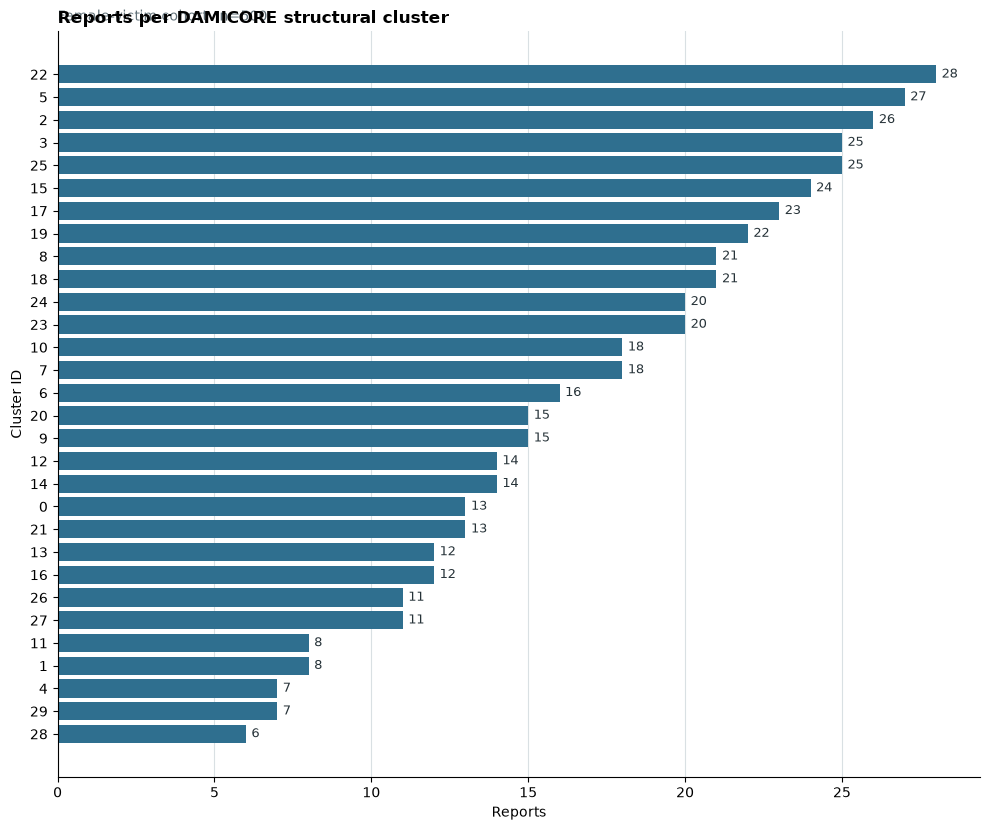

In [5]:
cluster_summary = (
    membership.groupby("cluster")
    .size()
    .rename("report_count")
    .reset_index()
    .sort_values("report_count")
)

figure, axis = plt.subplots(figsize=(10, max(6, len(cluster_summary) * 0.28)))
bars = axis.barh(
    cluster_summary["cluster"].astype(str),
    cluster_summary["report_count"],
    color="#2F6F8F",
)
axis.bar_label(bars, padding=4, color="#263238", fontsize=9)
axis.set_title("Reports per DAMICORE structural cluster", loc="left", weight="bold")
axis.text(
    0, 1.01, f"Female-victim cohort · n={len(membership):,}",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom"
)
axis.set_xlabel("Reports")
axis.set_ylabel("Cluster ID")
axis.set_xlim(left=0)
axis.grid(axis="x", color="#D9E0E3", linewidth=0.8)
axis.set_axisbelow(True)
axis.spines[["top", "right"]].set_visible(False)
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

In [6]:
focus_source_hash = FOCUS_SOURCE_HASH or membership.iloc[0]["source_hash"]
focus_label = f"{focus_source_hash}.txt"

if focus_label not in distance_matrix.index:
    raise KeyError("The selected report is not part of this cohort.")

nearest_neighbors = (
    distance_matrix.loc[focus_label]
    .drop(focus_label)
    .nsmallest(5)
    .rename("ncd_distance")
    .rename_axis("label")
    .reset_index()
    .merge(membership[["label", "object_id", "cluster"]], on="label")
    [["object_id", "cluster", "ncd_distance"]]
)
nearest_neighbors["ncd_distance"] = nearest_neighbors["ncd_distance"].round(4)
print("Five structurally nearest reports to the selected example:")
display(nearest_neighbors)

Five structurally nearest reports to the selected example:


,object_id,cluster,ncd_distance
0,file_000313,0,0.1843
1,file_000234,0,0.2134
2,file_000384,0,0.2345
3,file_000031,18,0.2395
4,file_000391,0,0.2424


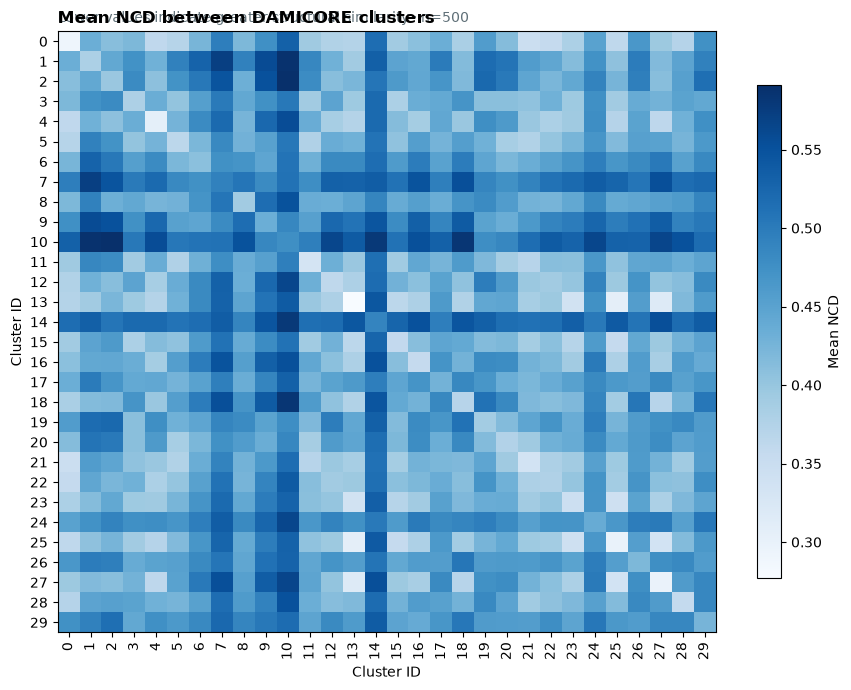

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.291,0.434,0.411,0.419,0.360,0.370,0.423,0.496,0.419,0.474,...,0.413,0.346,0.357,0.380,0.450,0.363,0.465,0.395,0.371,0.474
1,0.434,0.380,0.442,0.473,0.430,0.492,0.530,0.572,0.493,0.557,...,0.508,0.457,0.444,0.414,0.472,0.406,0.498,0.416,0.448,0.492
2,0.411,0.442,0.397,0.481,0.407,0.471,0.504,0.548,0.433,0.552,...,0.501,0.445,0.423,0.441,0.490,0.424,0.494,0.411,0.453,0.514
3,0.419,0.473,0.481,0.379,0.434,0.403,0.454,0.500,0.442,0.474,...,0.410,0.405,0.429,0.393,0.475,0.390,0.437,0.427,0.449,0.442
4,0.360,0.430,0.407,0.434,0.305,0.426,0.481,0.520,0.425,0.523,...,0.462,0.398,0.381,0.393,0.477,0.372,0.449,0.364,0.430,0.475
5,0.370,0.492,0.471,0.403,0.426,0.365,0.421,0.483,0.428,0.451,...,0.386,0.376,0.402,0.423,0.468,0.417,0.453,0.451,0.424,0.463
6,0.423,0.530,0.504,0.454,0.481,0.421,0.409,0.474,0.470,0.445,...,0.421,0.435,0.451,0.469,0.496,0.466,0.483,0.503,0.451,0.483
7,0.496,0.572,0.548,0.500,0.520,0.483,0.474,0.492,0.506,0.481,...,0.473,0.490,0.511,0.520,0.536,0.526,0.507,0.554,0.517,0.523
8,0.419,0.493,0.433,0.442,0.425,0.428,0.470,0.506,0.391,0.517,...,0.457,0.428,0.425,0.442,0.482,0.439,0.445,0.452,0.461,0.487
9,0.474,0.557,0.552,0.474,0.523,0.451,0.445,0.481,0.517,0.434,...,0.435,0.463,0.488,0.499,0.526,0.497,0.512,0.536,0.491,0.503


In [7]:
cluster_ids = sorted(membership["cluster"].unique())
cluster_distance = pd.DataFrame(index=cluster_ids, columns=cluster_ids, dtype=float)

for row_cluster in cluster_ids:
    row_labels = membership.loc[membership["cluster"] == row_cluster, "label"].tolist()
    for column_cluster in cluster_ids:
        column_labels = membership.loc[
            membership["cluster"] == column_cluster, "label"
        ].tolist()
        block = distance_matrix.loc[row_labels, column_labels].to_numpy()
        if row_cluster == column_cluster:
            values = block[np.triu_indices_from(block, k=1)]
        else:
            values = block.ravel()
        cluster_distance.loc[row_cluster, column_cluster] = (
            values.mean() if values.size else np.nan
        )

figure, axis = plt.subplots(figsize=(9, 7))
image = axis.imshow(cluster_distance, cmap="Blues", aspect="auto")
axis.set_title("Mean NCD between DAMICORE clusters", loc="left", weight="bold")
axis.text(
    0, 1.01, f"Lower values indicate greater structural similarity · n={len(membership):,}",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom"
)
axis.set_xlabel("Cluster ID")
axis.set_ylabel("Cluster ID")
axis.set_xticks(range(len(cluster_ids)), labels=cluster_ids, rotation=90)
axis.set_yticks(range(len(cluster_ids)), labels=cluster_ids)
colorbar = figure.colorbar(image, ax=axis, shrink=0.82)
colorbar.set_label("Mean NCD")
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

display(cluster_distance.round(3))

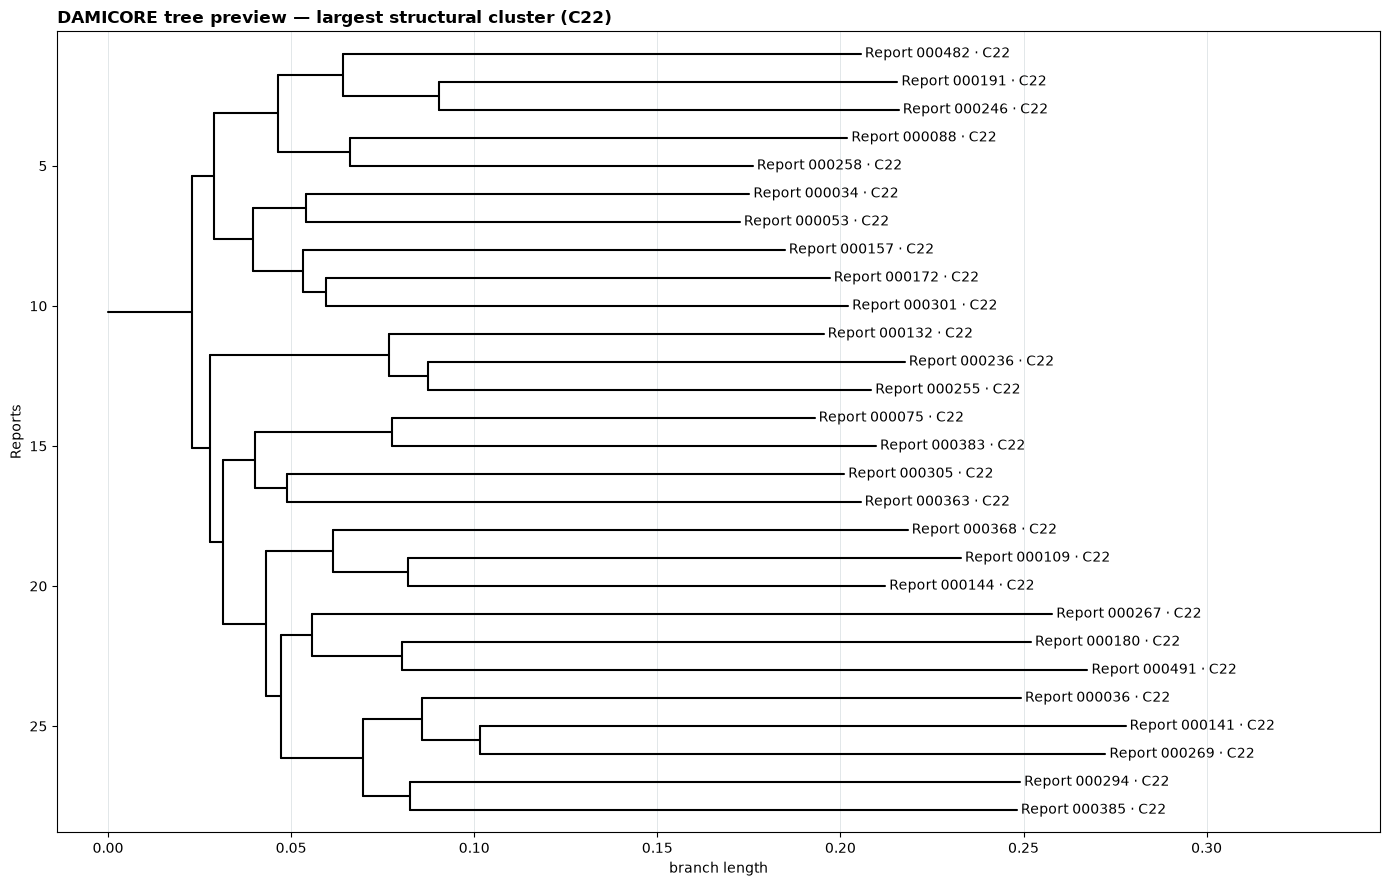

Printable tree saved to /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/results/01_damicore/tree.pdf
Newick artifact: /Users/erickpatrickbarcelos/codes/research/artifacts/female_abuse_2026_h1/work/01_damicore/run/tree.nwk


In [8]:
tree = Phylo.read(StringIO(tree_newick), "newick")
object_labels = {
    row.object_id: f"Report {row.object_id.removeprefix('file_')} · C{row.cluster}"
    for row in membership.itertuples()
}

largest_cluster = int(cluster_summary.iloc[-1]["cluster"])
largest_cluster_objects = set(
    membership.loc[membership["cluster"] == largest_cluster, "object_id"]
)
preview_tree = deepcopy(tree)
for terminal in list(preview_tree.get_terminals()):
    if terminal.name not in largest_cluster_objects:
        preview_tree.prune(terminal)
for terminal in preview_tree.get_terminals():
    terminal.name = object_labels[terminal.name]

figure, axis = plt.subplots(figsize=(14, max(8, len(largest_cluster_objects) * 0.32)))
Phylo.draw(
    preview_tree,
    axes=axis,
    do_show=False,
    show_confidence=False,
    label_func=lambda node: node.name if node.is_terminal() else None,
)
axis.set_title(
    f"DAMICORE tree preview — largest structural cluster (C{largest_cluster})",
    loc="left", weight="bold"
)
axis.set_ylabel("Reports")
axis.grid(axis="x", color="#E2E7E9", linewidth=0.7)
figure.patch.set_facecolor("white")
axis.set_facecolor("white")
figure.tight_layout()
plt.show()

printable_tree = deepcopy(tree)
for terminal in printable_tree.get_terminals():
    terminal.name = object_labels[terminal.name]

pdf_figure, pdf_axis = plt.subplots(figsize=(18, max(60, len(membership) * 0.16)))
Phylo.draw(
    printable_tree,
    axes=pdf_axis,
    do_show=False,
    show_confidence=False,
    label_func=lambda node: node.name if node.is_terminal() else None,
)
pdf_axis.set_title("Full DAMICORE tree — female-victim cohort", loc="left", weight="bold")
pdf_figure.patch.set_facecolor("white")
pdf_axis.set_facecolor("white")
pdf_figure.savefig(TREE_PDF, bbox_inches="tight")
plt.close(pdf_figure)

escaped_newick = html.escape(tree_newick)
display(HTML(
    f"""
    <details>
      <summary>Show full Newick tree</summary>
      <pre style="max-height:24rem;overflow:auto;white-space:pre-wrap">{escaped_newick}</pre>
    </details>
    """
))
print(f"Printable tree saved to {TREE_PDF}")
print(f"Newick artifact: {RUN_DIR / 'tree.nwk'}")

## 4. Persist safe summaries and checks

In [9]:
cluster_summary.sort_values("cluster").to_csv(CLUSTER_SUMMARY_FILE, index=False)
safe_run_summary = {
    "status": run_report["status"],
    "object_count": int(run_report["object_count"]),
    "pair_count": int(run_report["pair_count"]),
    "community_count": int(run_report["community_count"]),
    "modularity": float(run_report["modularity"]),
    "ncd_min": float(run_report["ncd_min"]),
    "ncd_max": float(run_report["ncd_max"]),
    "warnings": run_report["warnings"],
}
RUN_SUMMARY_FILE.write_text(
    json.dumps(safe_run_summary, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
write_manifest(
    PATHS,
    CONFIG,
    {
        "damicore_status": safe_run_summary["status"],
        "damicore_objects": safe_run_summary["object_count"],
        "structural_clusters": safe_run_summary["community_count"],
    },
)
for public_artifact in (CLUSTER_SUMMARY_FILE, RUN_SUMMARY_FILE):
    assert_public_artifact_safe(public_artifact)

assert safe_run_summary["status"] == "completed"
assert safe_run_summary["object_count"] == CONFIG.sample_size
assert cluster_summary["report_count"].sum() == CONFIG.sample_size

display(cluster_summary.sort_values("report_count", ascending=False).head(10))
print(f"DAMICORE status: {safe_run_summary['status']}")
print(f"Objects: {safe_run_summary['object_count']:,}")
print(f"Observed structural clusters: {safe_run_summary['community_count']:,}")
print("These clusters are structural groups, not confirmed abuse typologies.")


,cluster,report_count
22,22,28
5,5,27
2,2,26
3,3,25
25,25,25
15,15,24
17,17,23
19,19,22
8,8,21
18,18,21


DAMICORE status: completed
Objects: 500
Observed structural clusters: 30
These clusters are structural groups, not confirmed abuse typologies.


## Takeaways

DAMICORE supplies a compression-based structural baseline. Cluster size, NCD, and the tree describe similarity in serialized reports; the next notebook adds source categories and context before any social interpretation.